# Evaluator

In [1]:
from rail.core.stage import RailStage
from rail.evaluation.dist_to_point_evaluator import DistToPointEvaluator

import numpy as np
import qp
import tables_io

In [2]:
base_path = '/Users/leo/Projects/LBG_cosmology/pipeline_outputs/22Jun26/flexzboost_100kSamples'
data = tables_io.read(base_path + 'data.pq')
meta = tables_io.read(base_path + 'meta.pq')

yvals = np.stack(data['yvals'].values)
xvals = np.stack(meta['xvals'].values)[0]

pz_ensemble = qp.Ensemble(qp.interp, data = dict(xvals = xvals, yvals = yvals))

column_list None
column_list None


In [3]:
outputs_ancil = tables_io.read(base_path + 'ancil.pq')

column_list None


In [10]:
evaluator = DistToPointEvaluator.make_stage(
                                            name = "evaluator",
                                            metrics = ['brier', 'pit', 'cdeloss'],
                                            reference_dictionary_key = 'true_z',
                                            hdf5_groupname = "",
                                            metric_integration_limits = [0, 3],
                                            dx = 0.01,
                                            )

In [11]:
evaluation = evaluator.evaluate(pz_ensemble, outputs_ancil)

Inserting handle into data store.  input: None, evaluator
Inserting handle into data store.  truth: None, evaluator
Requested metrics: ['brier', 'pit', 'cdeloss']
Processing 0 running evaluator on chunk 0 - 20000.


Inserting handle into data store.  output_evaluator: inprogress_output_evaluator.hdf5, evaluator
Inserting handle into data store.  summary_evaluator: inprogress_summary_evaluator.hdf5, evaluator
Inserting handle into data store.  single_distribution_summary_evaluator: inprogress_single_distribution_summary_evaluator.hdf5, evaluator


In [15]:
evaluation['single_distribution_summary'].data

{'pit': Ensemble(the_class=quant,shape=(1, 98))}

In [23]:
evaluation['single_distribution_summary'].data['pit'].median()

0.5267333078045427

In [ ]:
help(evaluation['output'])

In [40]:
import matplotlib.pyplot as plt
plt.style.use('/Users/leo/Projects/LBG_cosmology/code/umap_nz_cal.mplstyle')

<Axes: >

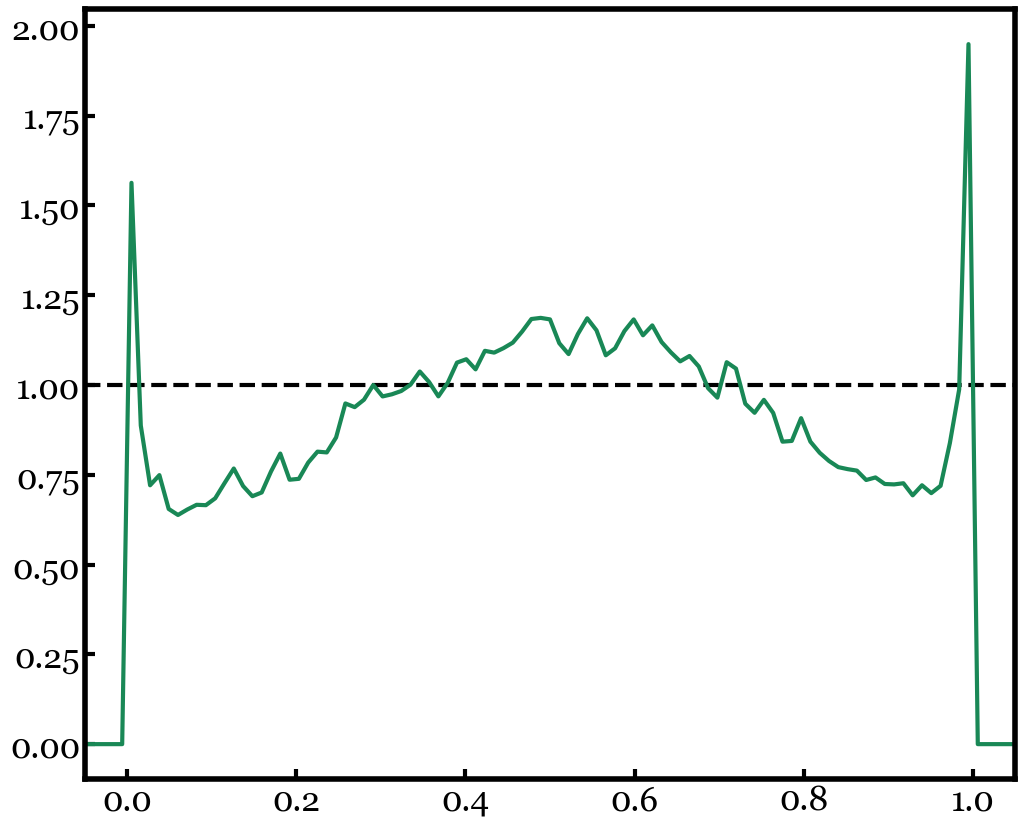

In [45]:
fig = plt.figure()
ax = fig.add_subplot()

ax.set_xlim(-0.05, 1.05)
ax.axhline(1, color = 'black', linestyle = '--')
evaluation['single_distribution_summary'].read()['pit'].plot(axes = ax)

In [47]:
help(evaluation['single_distribution_summary'].read()['pit'])

Help on Ensemble in module qp.core.ensemble object:

class Ensemble(builtins.object)
 |  Ensemble(
 |      the_class: Pdf_gen,
 |      data: Mapping,
 |      ancil: Optional[Mapping] = None,
 |      method: Optional[str] = None
 |  )
 |
 |  An object comprised of one or more distributions with the same parameterization.
 |
 |
 |  The Ensemble allows you to perform operations on the group of parameterizations as a whole.
 |  An Ensemble has three main data components, the last of which is optional:
 |
 |  1. The metadata: this contains information about the parameterization, and
 |     the coordinates of the parameterization.
 |  2. The object data: this contains the data that is unique to each distribution,
 |     for example the values that correspond to the coordinates.
 |  3. The ancillary data (optional): this contains data points where there is one data point
 |     for each distribution in the ensemble. There can be many of these columns or
 |     arrays in the ancillary data tab

In [ ]:
tables_io.read('/Users/leo/Projects/LBG_cosmology/code/RAIL_UMAP/src/evaluation/output_evaluator.hdf5')